In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

np.random.seed(42)
N, S = 500, 12


9(a): Simulate SARMA(1,0)_12  —  Xt = 0.9 Xt-12 + Wt

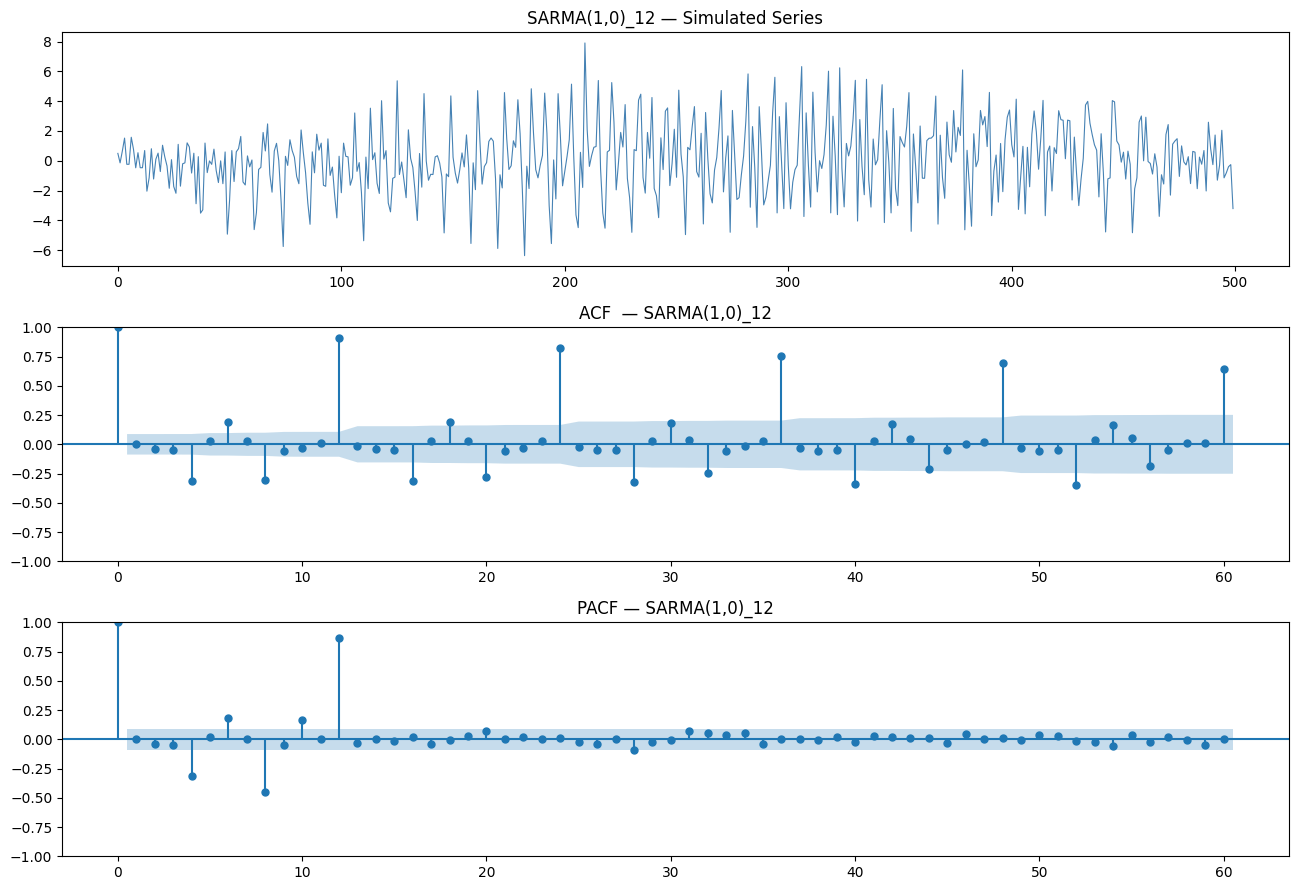

In [2]:
W     = np.random.randn(N)
X_sar = np.zeros(N)
for t in range(N):
    X_sar[t] = 0.9 * (X_sar[t - S] if t >= S else 0.0) + W[t]
X_sar = pd.Series(X_sar, name='SARMA(1,0)_12')

fig, axes = plt.subplots(3, 1, figsize=(13, 9))
axes[0].plot(X_sar.values, color='steelblue', lw=0.8)
axes[0].set_title('SARMA(1,0)_12 — Simulated Series')
plot_acf (X_sar, lags=60, ax=axes[1], title='ACF  — SARMA(1,0)_12')
plot_pacf(X_sar, lags=60, ax=axes[2], title='PACF — SARMA(1,0)_12', method='ywm')
plt.tight_layout()
plt.show()


9(a): Simulate ARMA(0,1) x SARMA(1,0)_12  —  Xt = 0.8 Xt-12 + Wt - 0.5 Wt-1

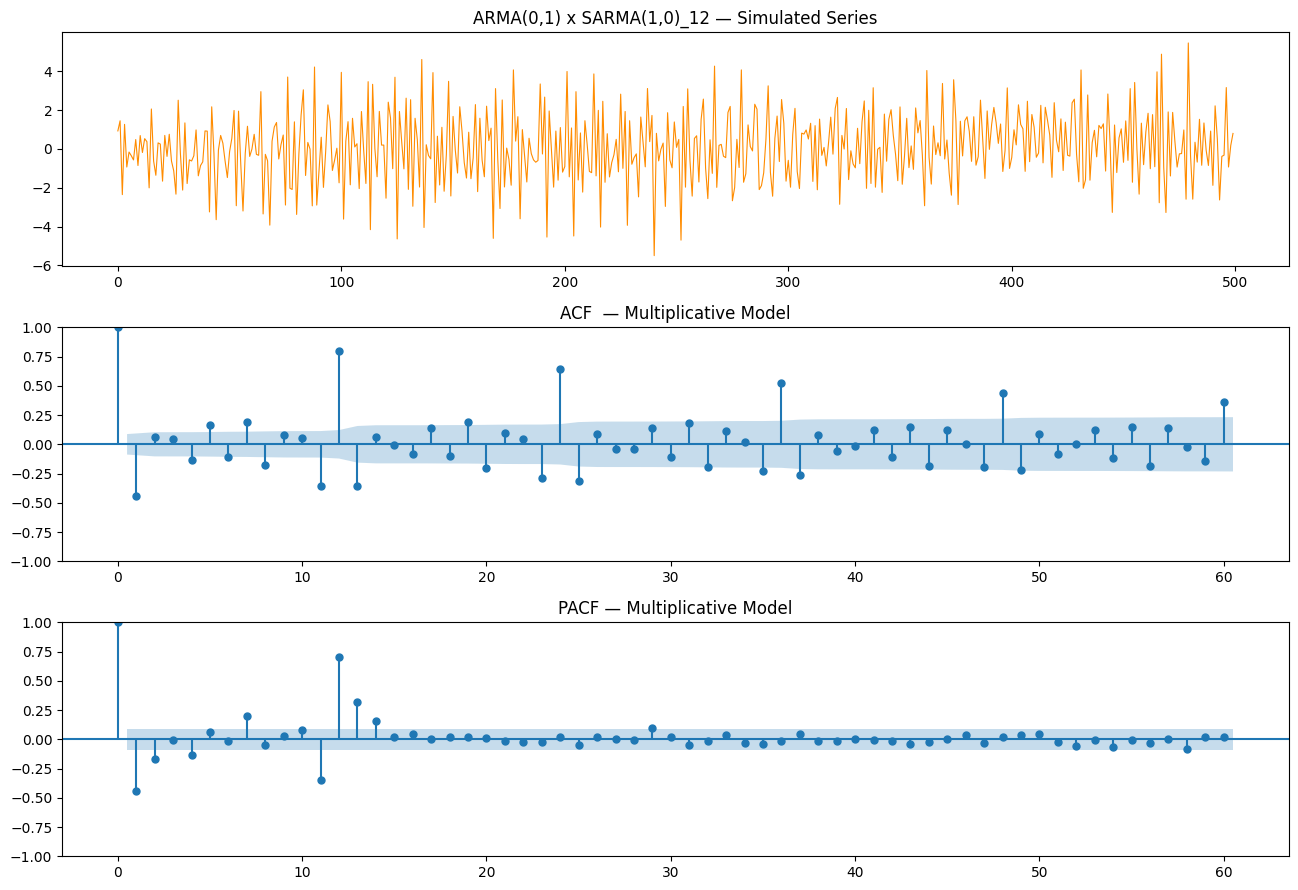

In [3]:
W2    = np.random.randn(N)
X_mul = np.zeros(N)
for t in range(N):
    X_mul[t] = 0.8 * (X_mul[t - S] if t >= S else 0.0) + W2[t] - 0.5 * (W2[t-1] if t >= 1 else 0.0)
X_mul = pd.Series(X_mul, name='ARMA(0,1)xSARMA(1,0)_12')

fig, axes = plt.subplots(3, 1, figsize=(13, 9))
axes[0].plot(X_mul.values, color='darkorange', lw=0.8)
axes[0].set_title('ARMA(0,1) x SARMA(1,0)_12 — Simulated Series')
plot_acf (X_mul, lags=60, ax=axes[1], title='ACF  — Multiplicative Model')
plot_pacf(X_mul, lags=60, ax=axes[2], title='PACF — Multiplicative Model', method='ywm')
plt.tight_layout()
plt.show()


9(b): Load AirPassengers Dataset

In [4]:
CSV_PATH = 'AirPassengers.csv'

try:
    df = pd.read_csv(CSV_PATH)
    df[df.columns[0]] = pd.to_datetime(df[df.columns[0]], infer_datetime_format=True)
    df.set_index(df.columns[0], inplace=True)
    df.index.freq = 'MS'
    air = df[df.columns[0]].astype(float)
except Exception:
    from statsmodels.datasets import get_rdataset
    air = pd.Series(get_rdataset('AirPassengers', 'datasets').data['value'].values,
                    index=pd.date_range('1949-01', periods=144, freq='MS'),
                    name='Passengers')

print(f'{len(air)} obs  |  {air.index[0].date()} -> {air.index[-1].date()}')
print(air.describe().round(2))


144 obs  |  1949-01-01 -> 1960-12-01
count    144.00
mean     280.30
std      119.97
min      104.00
25%      180.00
50%      265.50
75%      360.50
max      622.00
Name: Passengers, dtype: float64


9(b): Transformations & Plots

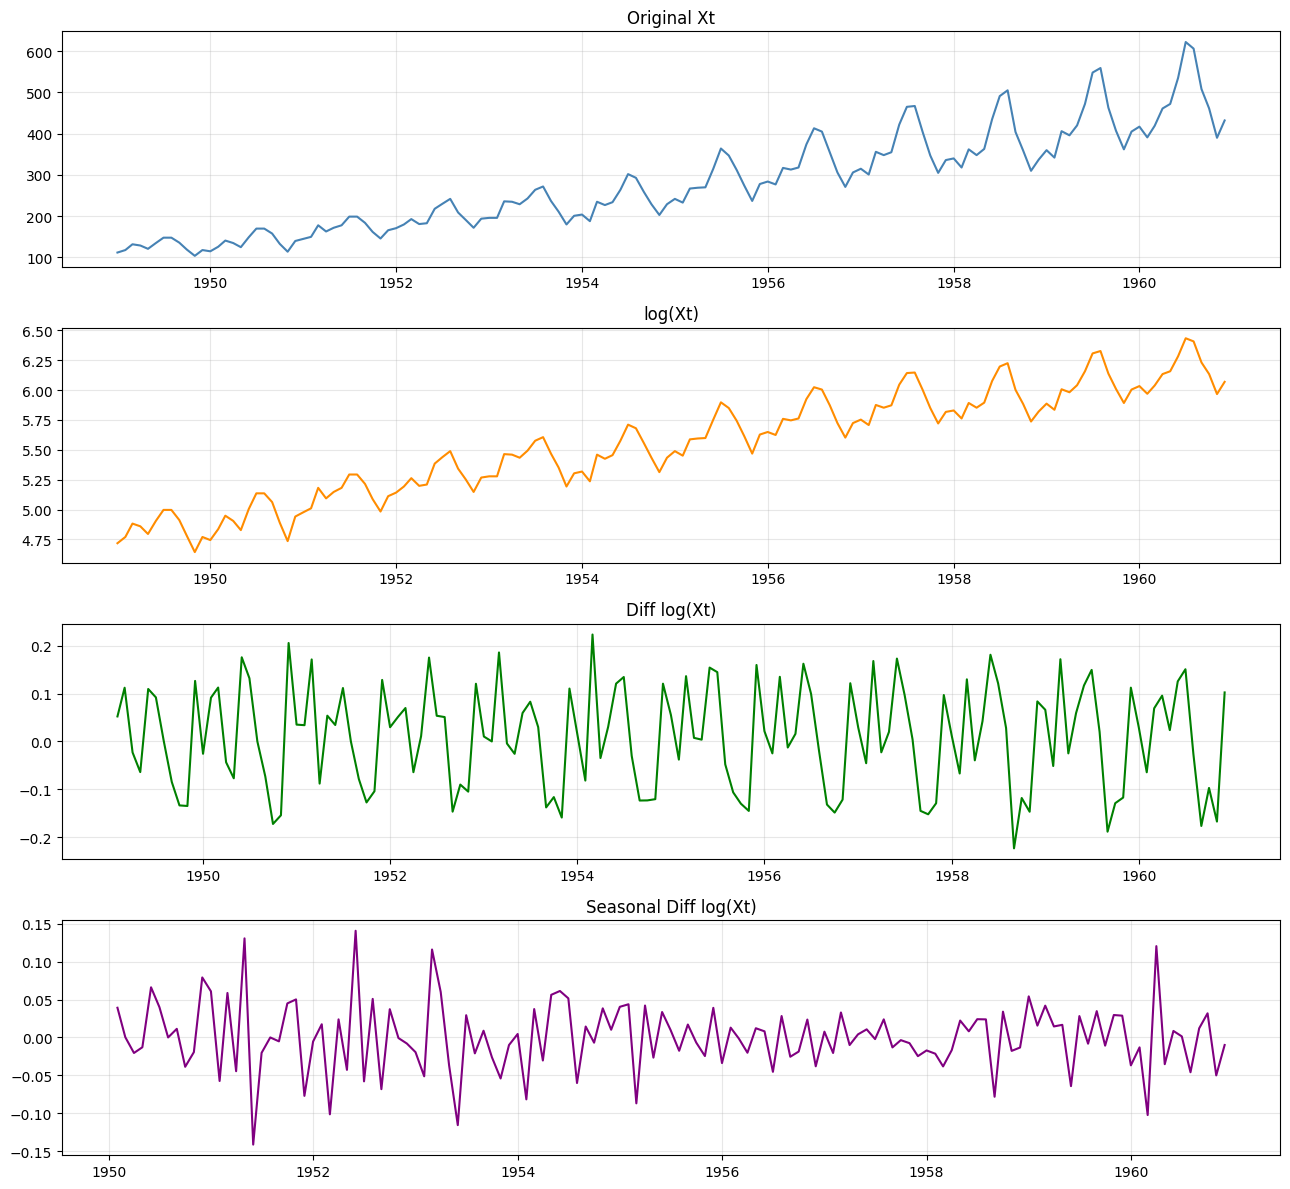

In [5]:
log_air    = np.log(air)
log_diff   = log_air.diff(1).dropna()
log_diff12 = log_air.diff(12).diff(1).dropna()

fig, axes = plt.subplots(4, 1, figsize=(13, 12))
axes[0].plot(air,        color='steelblue');  axes[0].set_title('Original Xt')
axes[1].plot(log_air,    color='darkorange'); axes[1].set_title('log(Xt)')
axes[2].plot(log_diff,   color='green');      axes[2].set_title('Diff log(Xt)')
axes[3].plot(log_diff12, color='purple');     axes[3].set_title('Seasonal Diff log(Xt)')
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


9(b): ACF & PACF for Each Transform

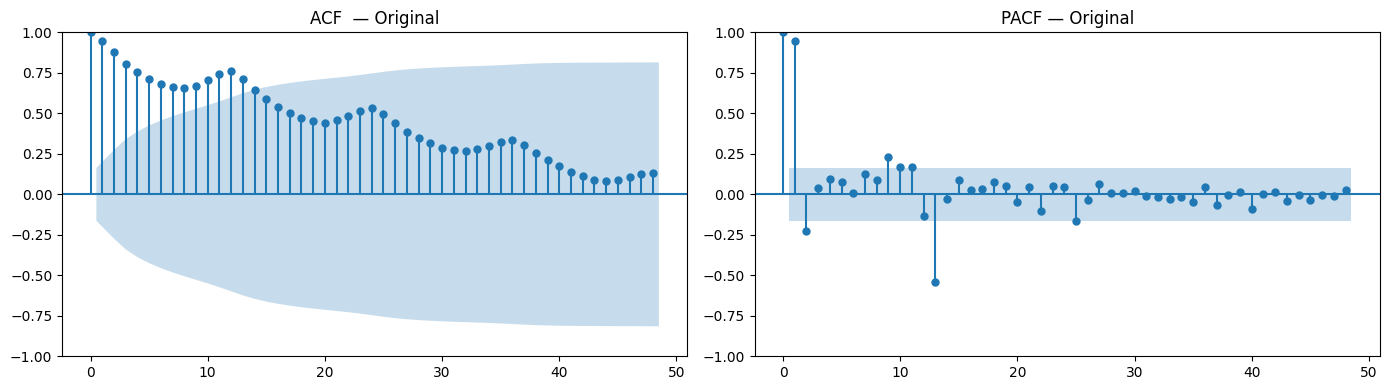

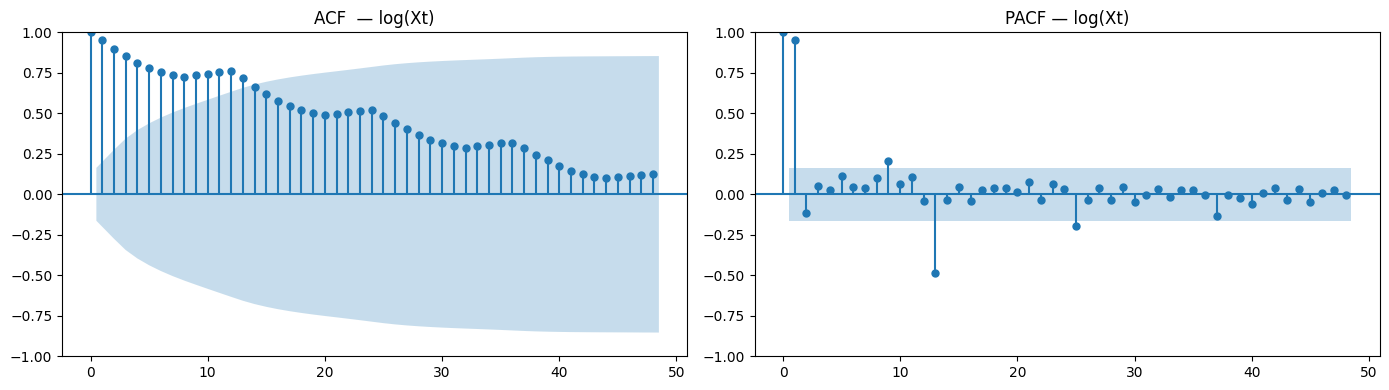

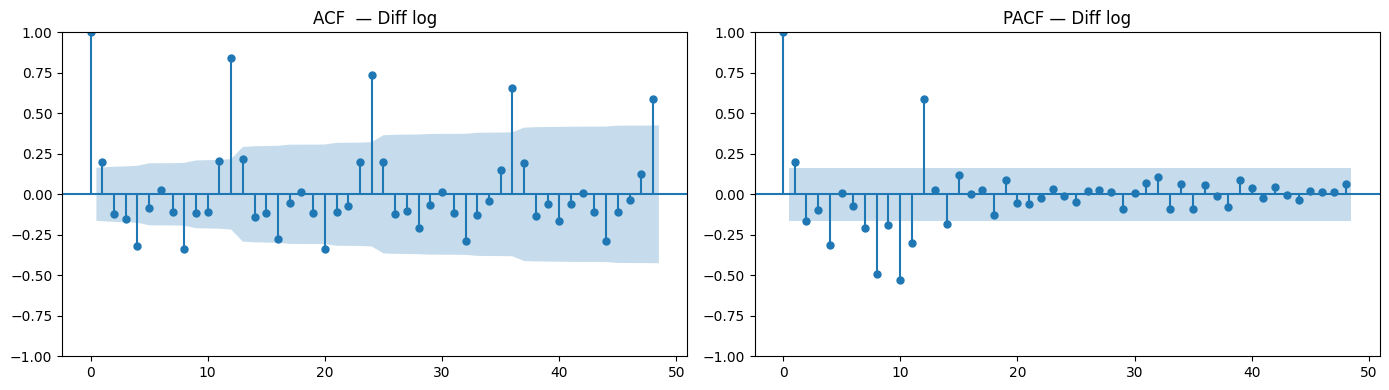

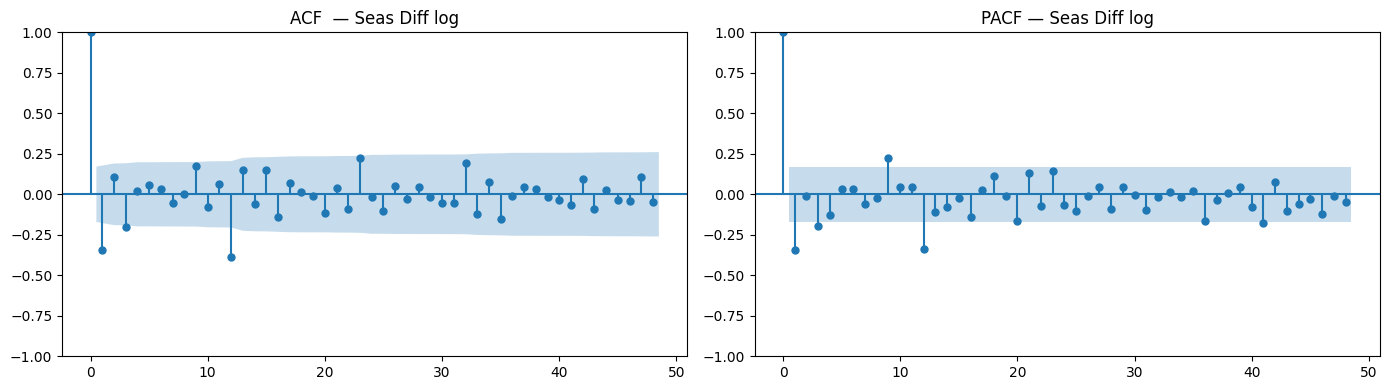

In [6]:
for label, s in [('Original', air), ('log(Xt)', log_air),
                  ('Diff log', log_diff), ('Seas Diff log', log_diff12)]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf (s, lags=48, ax=axes[0], title=f'ACF  — {label}')
    plot_pacf(s, lags=48, ax=axes[1], title=f'PACF — {label}', method='ywm')
    plt.tight_layout()
    plt.show()


9(b): ADF Stationarity Tests

In [7]:
for label, s in [('log(Xt)', log_air), ('Diff log', log_diff), ('Seas Diff log', log_diff12)]:
    r = adfuller(s, autolag='AIC')
    print(f'ADF [{label:15s}]  p={r[1]:.6f}  -> {"Stationary" if r[1] < 0.05 else "Non-Stationary"}')


ADF [log(Xt)        ]  p=0.422367  -> Non-Stationary
ADF [Diff log       ]  p=0.071121  -> Non-Stationary
ADF [Seas Diff log  ]  p=0.000249  -> Stationary


9(b): Fit SARIMA Models on log(AirPassengers)

In [8]:
SARIMA_ORDERS = {
    'ARIMA(0,1,1)x(0,1,1)_12': {'order': (0,1,1), 'seasonal_order': (0,1,1,12)},
    'ARIMA(1,1,0)x(0,1,1)_12': {'order': (1,1,0), 'seasonal_order': (0,1,1,12)},
}

fitted_sarima = {}
for name, params in SARIMA_ORDERS.items():
    m = SARIMAX(log_air,
                order=params['order'], seasonal_order=params['seasonal_order'],
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    fitted_sarima[name] = m
    print(m.summary())


                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  144
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 220.722
Date:                            Sun, 29 Mar 2026   AIC                           -435.444
Time:                                    21:46:03   BIC                           -427.157
Sample:                                01-01-1949   HQIC                          -432.079
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4326      0.075     -5.747      0.000      -0.580      -0.285
ma.S.L12      -0.5476      0.098   

9(b): Residual Diagnostics

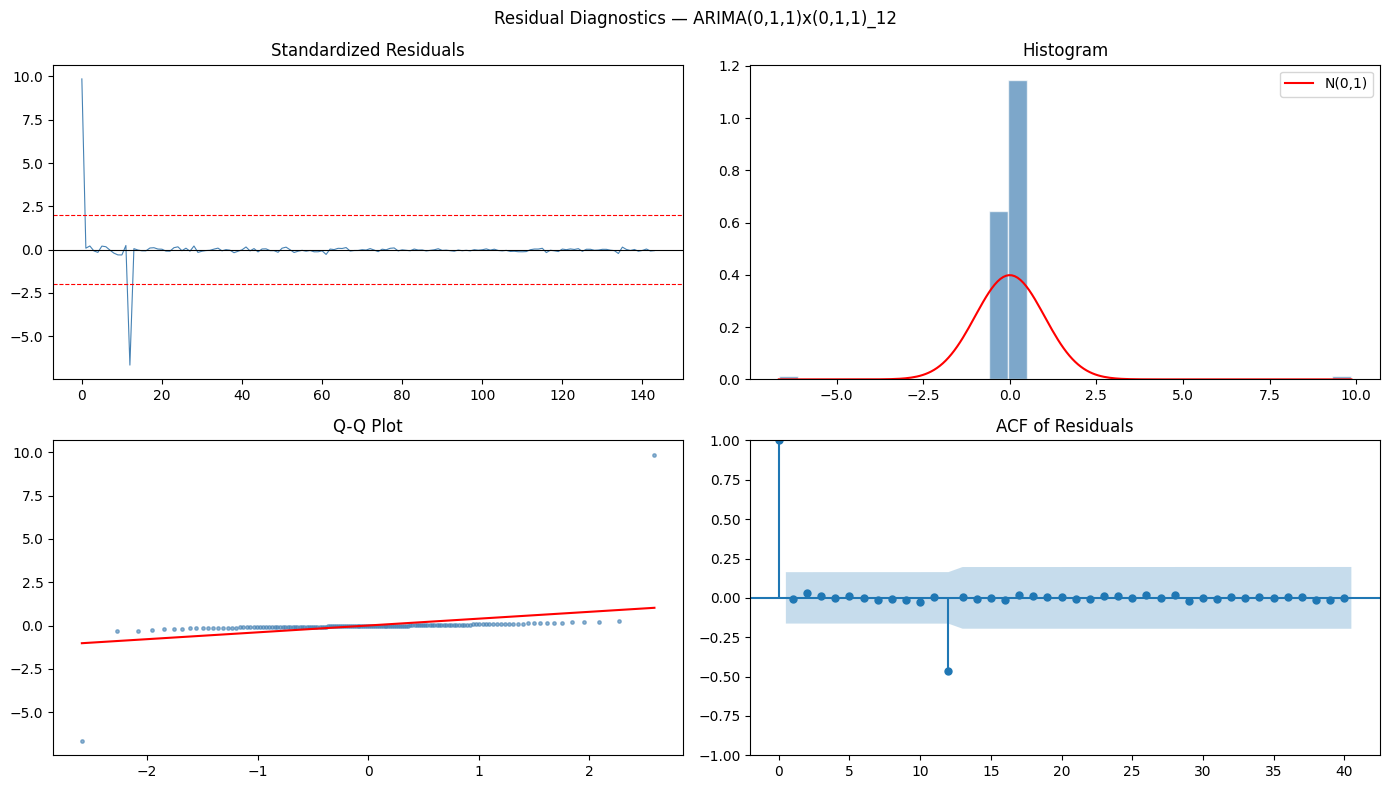

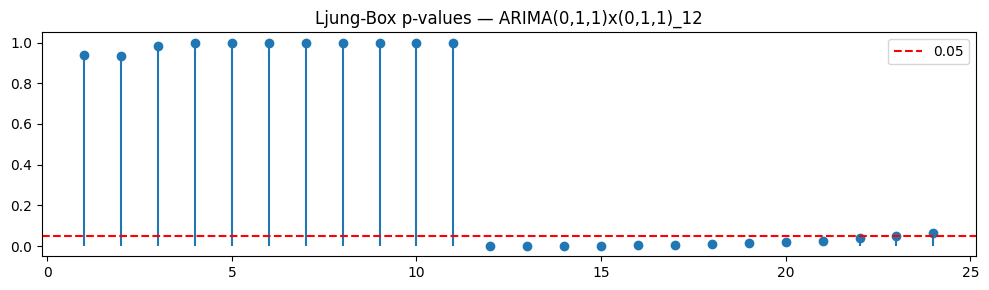

ARIMA(0,1,1)x(0,1,1)_12
  Ljung-Box  : Autocorrelation present
  ARCH p     : 1.0000  -> No ARCH
  Shapiro-Wilk p: 0.0000  -> Non-Normal


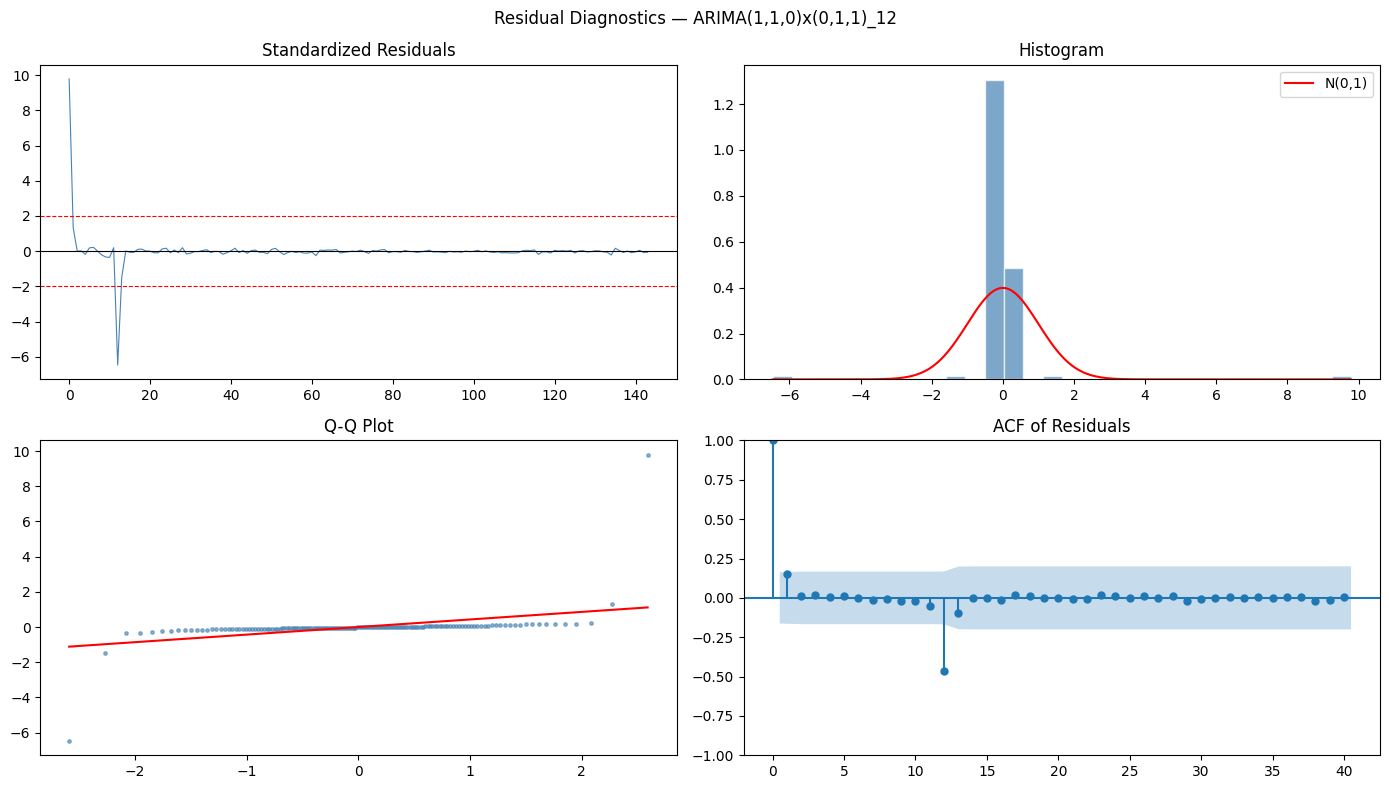

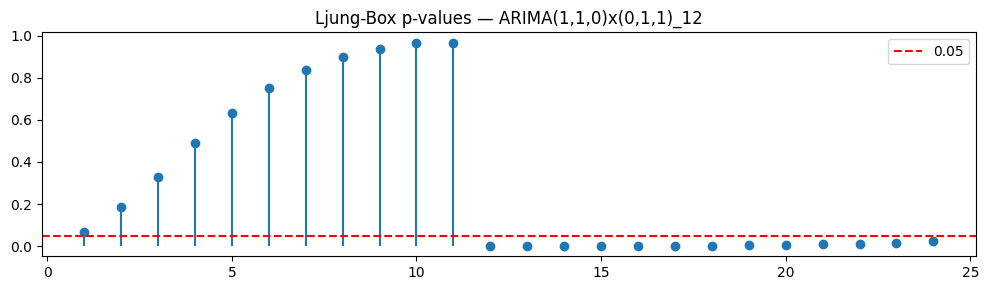

ARIMA(1,1,0)x(0,1,1)_12
  Ljung-Box  : Autocorrelation present
  ARCH p     : 1.0000  -> No ARCH
  Shapiro-Wilk p: 0.0000  -> Non-Normal


In [9]:
diag_results = {}

for name, model in fitted_sarima.items():
    residuals = model.resid.dropna()
    std_res   = (residuals - residuals.mean()) / residuals.std()

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f'Residual Diagnostics — {name}', fontsize=12)

    axes[0,0].plot(std_res.values, color='steelblue', lw=0.8)
    axes[0,0].axhline(0, color='black', lw=0.8)
    axes[0,0].axhline( 2, color='red', ls='--', lw=0.8)
    axes[0,0].axhline(-2, color='red', ls='--', lw=0.8)
    axes[0,0].set_title('Standardized Residuals')

    axes[0,1].hist(std_res, bins=30, density=True, color='steelblue', alpha=0.7, edgecolor='white')
    xr = np.linspace(std_res.min(), std_res.max(), 200)
    axes[0,1].plot(xr, stats.norm.pdf(xr), 'r-', lw=1.5, label='N(0,1)')
    axes[0,1].set_title('Histogram'); axes[0,1].legend()

    (osm, osr), (slope, intercept, _) = stats.probplot(std_res, dist='norm')
    axes[1,0].scatter(osm, osr, s=6, color='steelblue', alpha=0.6)
    axes[1,0].plot(osm, slope * np.array(osm) + intercept, 'r-', lw=1.5)
    axes[1,0].set_title('Q-Q Plot')

    plot_acf(residuals, lags=40, ax=axes[1,1], title='ACF of Residuals')

    plt.tight_layout()
    plt.show()

    lb = acorr_ljungbox(residuals, lags=list(range(1, 25)), return_df=True)
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.stem(range(1, 25), lb['lb_pvalue'], markerfmt='C0o', linefmt='C0-', basefmt=' ')
    ax.axhline(0.05, color='red', ls='--', label='0.05')
    ax.set_title(f'Ljung-Box p-values — {name}')
    ax.legend(); plt.tight_layout(); plt.show()

    lb_ok    = (lb['lb_pvalue'] > 0.05).all()
    arch_p   = het_arch(residuals)[1]
    _, sw_p  = stats.shapiro(std_res)

    print(f'{name}')
    print(f'  Ljung-Box  : {"White noise" if lb_ok else "Autocorrelation present"}')
    print(f'  ARCH p     : {arch_p:.4f}  -> {"No ARCH" if arch_p > 0.05 else "ARCH present"}')
    print(f'  Shapiro-Wilk p: {sw_p:.4f}  -> {"Normal" if sw_p > 0.05 else "Non-Normal"}')

    diag_results[name] = {'AIC': model.aic, 'BIC': model.bic,
                          'LjungBox_OK': lb_ok, 'No_ARCH': arch_p > 0.05, 'Normal': sw_p > 0.05}


9(b): Model Comparison & Best Model Selection

In [10]:
comp_df = pd.DataFrame(diag_results).T
print(comp_df.to_string())

best_name  = comp_df['BIC'].idxmin()
best_model = fitted_sarima[best_name]
print(f'\nBest by AIC: {comp_df["AIC"].idxmin()}')
print(f'Best by BIC: {best_name}')


                                AIC         BIC LjungBox_OK No_ARCH Normal
ARIMA(0,1,1)x(0,1,1)_12 -435.443532  -427.15701       False    True  False
ARIMA(1,1,0)x(0,1,1)_12 -437.525822 -429.213768       False    True  False

Best by AIC: ARIMA(1,1,0)x(0,1,1)_12
Best by BIC: ARIMA(1,1,0)x(0,1,1)_12


9(b): 12-Month Forecast

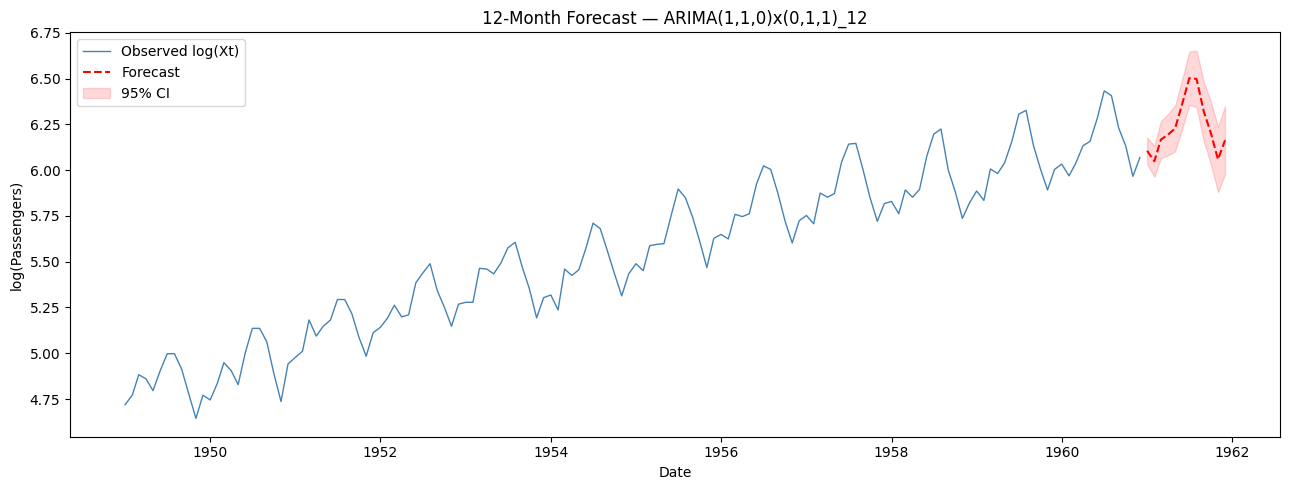

            Forecast log(Xt)  Forecast Passengers  Lower CI  Upper CI
1961-01-01            6.1057                448.4    6.0337    6.1778
1961-02-01            6.0486                423.5    5.9638    6.1334
1961-03-01            6.1664                476.5    6.0653    6.2675
1961-04-01            6.1944                490.0    6.0811    6.3077
1961-05-01            6.2278                506.6    6.1029    6.3527
1961-06-01            6.3638                580.5    6.2285    6.4992
1961-07-01            6.5026                666.8    6.3575    6.6476
1961-08-01            6.4981                663.9    6.3439    6.6522
1961-09-01            6.3197                555.4    6.1569    6.4825
1961-10-01            6.2042                494.8    6.0332    6.3751
1961-11-01            6.0585                427.7    5.8798    6.2372
1961-12-01            6.1630                474.8    5.9768    6.3492


In [11]:
forecast_result = best_model.get_forecast(steps=12)
fc_mean         = forecast_result.predicted_mean
fc_ci           = forecast_result.conf_int(alpha=0.05)

future_dates  = pd.date_range(start=log_air.index[-1], periods=13, freq='MS')[1:]
fc_mean.index = future_dates
fc_ci.index   = future_dates

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(log_air, color='steelblue', lw=1, label='Observed log(Xt)')
ax.plot(fc_mean, color='red', lw=1.5, ls='--', label='Forecast')
ax.fill_between(future_dates, fc_ci.iloc[:,0], fc_ci.iloc[:,1], color='red', alpha=0.15, label='95% CI')
ax.set_title(f'12-Month Forecast — {best_name}')
ax.set_xlabel('Date'); ax.set_ylabel('log(Passengers)'); ax.legend()
plt.tight_layout()
plt.show()

fc_df = pd.DataFrame({
    'Forecast log(Xt)'   : fc_mean.round(4),
    'Forecast Passengers': np.exp(fc_mean).round(1),
    'Lower CI'           : fc_ci.iloc[:,0].round(4),
    'Upper CI'           : fc_ci.iloc[:,1].round(4),
})
print(fc_df.to_string())
